In [37]:
from typing import Dict, TypedDict, List
import random
from langgraph.graph import StateGraph, END

In [38]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [39]:
def greeting_node(state: AgentState) -> AgentState:
    state["name"] = f"Hi there, {state["name"]}"
    state["counter"] = 0
    return state

def random_node(state: AgentState) -> AgentState:
    state["number"].append(random.randint(1, 10))
    state["counter"] += 1
    return state

def should_continue(state: AgentState) -> str:
    if state["counter"] < 5:
        print("ENTERING LOOP", state["counter"])
        return "loop"
    else:
        return "exit"

### Flow: greeting -> random -> random -> random -> random -> random -> END

In [40]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)
graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit": END,
    },
)

graph.set_entry_point("greeting")
app = graph.compile()

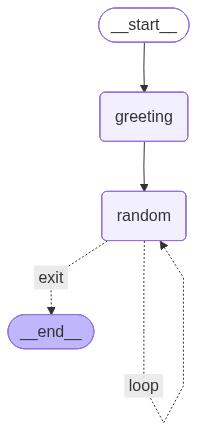

In [41]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [42]:
app.invoke({"name":"Shahariar", "number":[], "counter":-100})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, Shahariar', 'number': [9, 4, 2, 4, 3], 'counter': 5}